Ewaluacja dwóch modeli na zbiorze SUN:
ResNet18 (Places365)
CLIP ViT-B/32

In [1]:
import numpy as np
import pandas as pd
import os
import contextlib
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms as trn

import clip  

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import joblib
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Wczytanie danych 


In [2]:
mat_attrs  = scipy.io.loadmat('data/SUN/SUNAttributeDB/attributes.mat')
mat_images = scipy.io.loadmat('data/SUN/SUNAttributeDB/images.mat')
mat_labels = scipy.io.loadmat('data/SUN/SUNAttributeDB/attributeLabels_continuous.mat')

attributes_list = [item[0][0] for item in mat_attrs['attributes']]
images_list     = [item[0][0] for item in mat_images['images']]
labels_matrix   = mat_labels['labels_cv']

threshold      = 0.5
binary_labels  = (labels_matrix > threshold).astype(float)

df_sun = pd.DataFrame(binary_labels, columns=attributes_list)
df_sun.insert(0, 'image_id',  range(1, len(images_list) + 1))
df_sun.insert(1, 'file_path', images_list)
df_sun.insert(3, 'class_id',  df_sun['file_path'].apply(lambda x: x.split('/')[2]))

non_attr_cols = ['image_id', 'file_path', 'class_id']
attr_cols     = [c for c in df_sun.columns if c not in non_attr_cols]

print(f'Obrazy: {len(df_sun)}, atrybuty: {len(attr_cols)}, klasy scen: {df_sun["class_id"].nunique()}')
df_sun.head(3)

Obrazy: 14340, atrybuty: 102, klasy scen: 9681


,image_id,file_path,sailing/ boating,class_id,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,0.0,sun_aakbdcgfpksytcwj.jpg,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,0.0,sun_aaoktempcmudsvna.jpg,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,0.0,sun_abegcweqnetpdlrh.jpg,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#Do paska ładowania
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old

## 3. ResNet18 (Places365) 
Model pochodzi z: https://github.com/CSAILVision/places365  

In [4]:
model_file = 'models/resnet18_places365.pth'

conv_model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)

conv_model.fc = nn.Identity()  # cechy 512-d
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('ResNet18/Places365 załadowany. Wymiar cech: 512')

ResNet18/Places365 załadowany. Wymiar cech: 512


In [5]:
features_conv, labels_conv, paths_conv = [], [], []

conv_model.eval()
with torch.no_grad():
    for _, row in tqdm(df_sun.iterrows(), total=len(df_sun), desc='ResNet18 features'):
        img_path = os.path.join('data/SUN/images/', str(row['file_path']))
        try:
            img  = Image.open(img_path).convert('RGB')
            inp  = centre_crop(img).unsqueeze(0).to(DEVICE)
            feat = conv_model(inp).squeeze().cpu().numpy()
            features_conv.append(feat)
            labels_conv.append(row[attr_cols].values.astype(np.float32))
            paths_conv.append(img_path)
        except Exception as e:
            print(f'Błąd: {img_path}: {e}')

X_conv = np.array(features_conv)
y_conv = np.array(labels_conv)
paths_conv = np.array(paths_conv)
print(f'X_conv: {X_conv.shape}, y_conv: {y_conv.shape}')

ResNet18 features: 100%|██████████| 14340/14340 [01:56<00:00, 123.34it/s]

X_conv: (14340, 512), y_conv: (14340, 102)


In [6]:
X_tr_c, X_te_c, y_tr_c, y_te_c, paths_tr_c, paths_te_c = train_test_split(
    X_conv, y_conv, paths_conv, test_size=0.2, random_state=42
)

clf_conv = MultiOutputClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
with tqdm_joblib(tqdm(desc=f'ResNet18 – trening ({len(attr_cols)} atrybutów)', total=len(attr_cols))):
    clf_conv.fit(X_tr_c, y_tr_c)

y_pred_c  = clf_conv.predict(X_te_c)
y_proba_c = np.column_stack([p[:, 1] for p in clf_conv.predict_proba(X_te_c)])

results_conv = {
    'Exact Match Acc': accuracy_score(y_te_c, y_pred_c),
    'F1 Macro':        f1_score(y_te_c, y_pred_c, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_c, y_proba_c, average='macro'),
}

print('\n====== ResNet18 (Places365) + LogReg ======')
for k, v in results_conv.items():
    print(f'  {k}: {v:.4f}')

ResNet18 – trening (102 atrybutów): 100%|██████████| 102/102 [00:26<00:00, 11.09it/s]


====== ResNet18 (Places365) + LogReg ======
  Exact Match Acc: 0.0164
  F1 Macro: 0.4606
  ROC AUC Macro: 0.9194


### Wizualizacja błędów – ResNet18

Znaleziono 2821 obrazów z przynajmniej 1 błędem. Wyświetlam 2 przykłady...


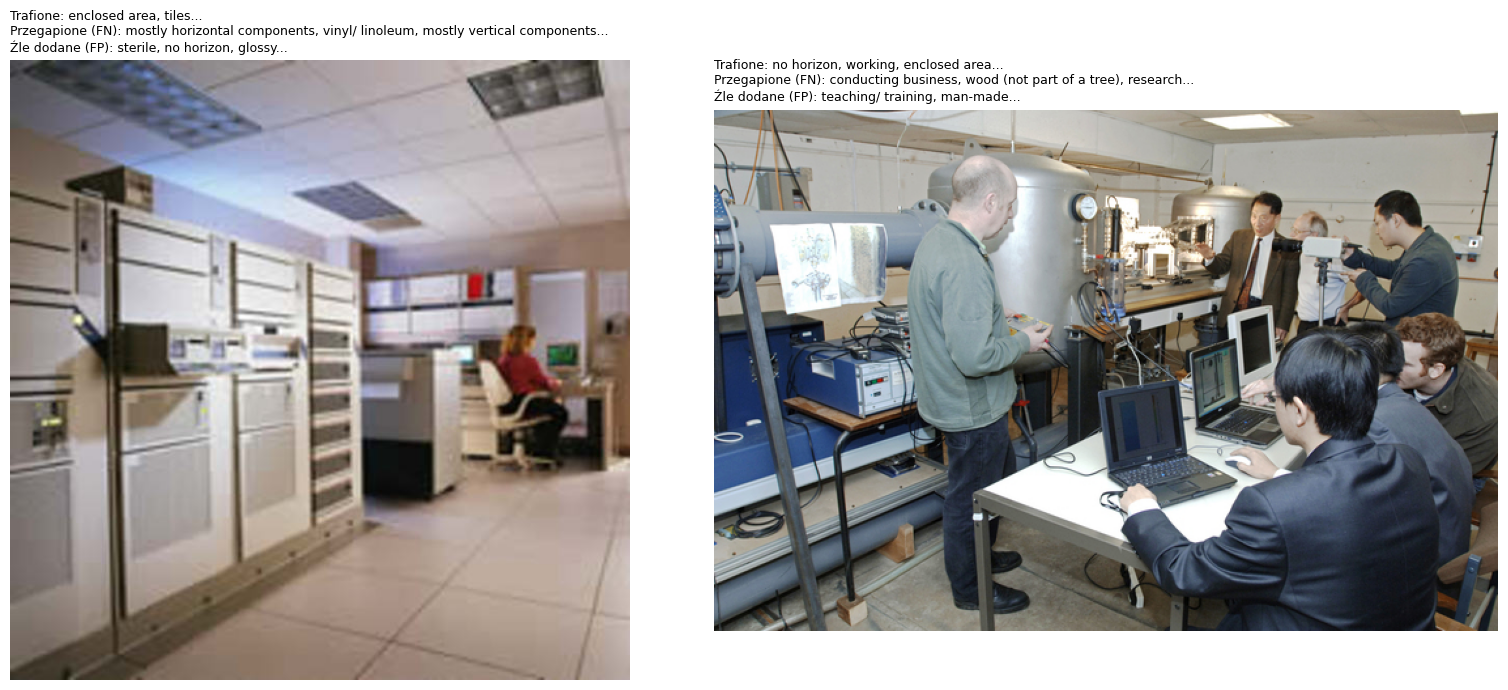

In [7]:
errors_per_sample = np.sum(y_pred_c != y_te_c, axis=1)
incorrect_indices = np.where(errors_per_sample > 0)[0]

if len(incorrect_indices) > 0:
    print(f'Znaleziono {len(incorrect_indices)} obrazów z przynajmniej 1 błędem. Wyświetlam 2 przykłady...')
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for i, idx in enumerate(incorrect_indices[:2]):
        true_attrs  = set([attr_cols[j] for j, v in enumerate(y_te_c[idx])  if v == 1])
        pred_attrs  = set([attr_cols[j] for j, v in enumerate(y_pred_c[idx]) if v == 1])
        fn = true_attrs - pred_attrs
        fp = pred_attrs - true_attrs
        ok = true_attrs & pred_attrs
        try:
            img = Image.open(paths_te_c[idx]).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title(
                f'Trafione: {", ".join(list(ok)[:3])}...\n'
                f'Przegapione (FN): {", ".join(list(fn)[:3])}...\n'
                f'Źle dodane (FP): {", ".join(list(fp)[:3])}...',
                fontsize=9, loc='left'
            )
            axes[i].axis('off')
        except Exception as e:
            print(f'Błąd wczytywania: {e}')
    plt.tight_layout()
    plt.show()
else:
    print('Model przewidział wszystkie atrybuty perfekcyjnie!')

## 4. CLIP ViT-B/32 

In [8]:
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print('CLIP załadowany. Wymiar embeddingu:', clip_model.visual.output_dim)

CLIP załadowany. Wymiar embeddingu: 512


In [9]:
features_clip, labels_clip, paths_clip_arr = [], [], []

with torch.no_grad():
    for _, row in tqdm(df_sun.iterrows(), total=len(df_sun), desc='CLIP image features'):
        img_path = os.path.join('data/SUN/images/', str(row['file_path']))
        try:
            img  = Image.open(img_path).convert('RGB')
            inp  = clip_preprocess(img).unsqueeze(0).to(DEVICE)
            feat = clip_model.encode_image(inp).squeeze().cpu().float().numpy()
            features_clip.append(feat)
            labels_clip.append(row[attr_cols].values.astype(np.float32))
            paths_clip_arr.append(img_path)
        except Exception as e:
            print(f'Błąd: {img_path}: {e}')

X_clip = np.array(features_clip)
y_clip = np.array(labels_clip)
paths_clip_arr = np.array(paths_clip_arr)
print(f'X_clip: {X_clip.shape}, y_clip: {y_clip.shape}')

CLIP image features: 100%|██████████| 14340/14340 [03:18<00:00, 72.15it/s] 11.09it/s]

X_clip: (14340, 512), y_clip: (14340, 102)


## 4a. CLIP – Linear Probe

In [10]:
X_tr_cl, X_te_cl, y_tr_cl, y_te_cl, paths_tr_cl, paths_te_cl = train_test_split(
    X_clip, y_clip, paths_clip_arr, test_size=0.2, random_state=42
)

clf_clip = MultiOutputClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
with tqdm_joblib(tqdm(desc=f'CLIP linear probe ({len(attr_cols)} atrybutów)', total=len(attr_cols))):
    clf_clip.fit(X_tr_cl, y_tr_cl)

y_pred_cl  = clf_clip.predict(X_te_cl)
y_proba_cl = np.column_stack([p[:, 1] for p in clf_clip.predict_proba(X_te_cl)])

results_clip_probe = {
    'Exact Match Acc': accuracy_score(y_te_cl, y_pred_cl),
    'F1 Macro':        f1_score(y_te_cl, y_pred_cl, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_cl, y_proba_cl, average='macro'),
}

print('\n====== CLIP ViT-B/32 + Linear Probe ======')
for k, v in results_clip_probe.items():
    print(f'  {k}: {v:.4f}')


====== CLIP ViT-B/32 + Linear Probe ======
  Exact Match Acc: 0.0153
  F1 Macro: 0.4697
  ROC AUC Macro: 0.9297


## 4b. CLIP – Zero-Shot detekcja atrybutów SUN

Dla każdego atrybutu tworzymy dwa prompty:
```
positive = "a photo of a place that is open area"
negative = "a photo of a place that is not open area"
```
Softmax nad podobieństwem kosinusowym daje prawdopodobieństwo obecności atrybutu.

In [11]:

pos_prompts = [f'a photo of a place that is {attr}' for attr in attr_cols]
neg_prompts = [f'a photo of a place that is not {attr}' for attr in attr_cols]

with torch.no_grad():
    pos_emb = clip_model.encode_text(clip.tokenize(pos_prompts, truncate=True).to(DEVICE)).float()
    neg_emb = clip_model.encode_text(clip.tokenize(neg_prompts, truncate=True).to(DEVICE)).float()
    pos_emb = pos_emb / pos_emb.norm(dim=-1, keepdim=True)
    neg_emb = neg_emb / neg_emb.norm(dim=-1, keepdim=True)


In [12]:
idx_all = np.arange(len(df_sun))
_, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42)

zs_probs = []

with torch.no_grad():
    for i in tqdm(idx_test, desc='CLIP zero-shot scoring'):
        img_path = paths_clip_arr[i]
        img  = Image.open(img_path).convert('RGB')
        inp  = clip_preprocess(img).unsqueeze(0).to(DEVICE)
        img_feat = clip_model.encode_image(inp).squeeze().float()
        img_feat = img_feat / img_feat.norm()

        sim_pos = img_feat @ pos_emb.T
        sim_neg = img_feat @ neg_emb.T
        probs   = torch.stack([sim_pos, sim_neg], dim=-1).mul(100).softmax(dim=-1)[:, 0]
        zs_probs.append(probs.cpu().numpy())

zs_probs = np.array(zs_probs)
zs_preds = (zs_probs >= 0.5).astype(int)
y_te_zs  = y_clip[idx_test]

results_clip_zs = {
    'Exact Match Acc': accuracy_score(y_te_zs, zs_preds),
    'F1 Macro':        f1_score(y_te_zs, zs_preds, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_zs, zs_probs, average='macro'),
}

print('\n====== CLIP Zero-Shot ======')
for k, v in results_clip_zs.items():
    print(f'  {k}: {v:.4f}')




























































































































































































































































































































































































CLIP zero-shot scoring: 100%|██████████| 2868/2868 [00:41<00:00, 68.45it/s]


====== CLIP Zero-Shot ======
  Exact Match Acc: 0.0000
  F1 Macro: 0.1863
  ROC AUC Macro: 0.7217


## 5. Porównanie modeli

CLIP linear probe (102 atrybutów): 100%|██████████| 102/102 [00:58<00:00,  1.75it/s]


                               Exact Match Acc  F1 Macro  ROC AUC Macro
Model                                                                  
ResNet18 (Places365) + LogReg         0.016388  0.460633       0.919440
CLIP ViT-B/32 + Linear Probe          0.015342  0.469740       0.929693
CLIP Zero-Shot                        0.000000  0.186349       0.721654


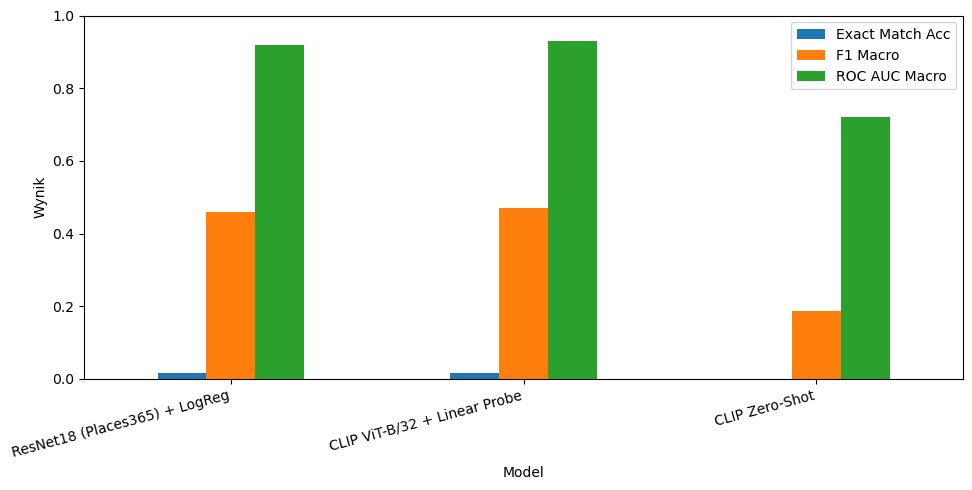

In [13]:
comparison = pd.DataFrame({
    'Model': ['ResNet18 (Places365) + LogReg', 'CLIP ViT-B/32 + Linear Probe', 'CLIP Zero-Shot'],
    'Exact Match Acc': [results_conv['Exact Match Acc'],       results_clip_probe['Exact Match Acc'],    results_clip_zs['Exact Match Acc']],
    'F1 Macro':        [results_conv['F1 Macro'],              results_clip_probe['F1 Macro'],           results_clip_zs['F1 Macro']],
    'ROC AUC Macro':   [results_conv['ROC AUC Macro'],         results_clip_probe['ROC AUC Macro'],      results_clip_zs['ROC AUC Macro']],
}).set_index('Model')

print(comparison.to_string())

comparison.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
plt.ylabel('Wynik')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 6. Per-atrybut analiza: CLIP zero-shot vs ResNet18

In [14]:
auc_conv_per = [roc_auc_score(y_te_c[:, j],  y_proba_c[:, j])  for j in range(len(attr_cols))]
auc_probe_per = [roc_auc_score(y_te_cl[:, j], y_proba_cl[:, j]) for j in range(len(attr_cols))]
auc_zs_per   = [roc_auc_score(y_te_zs[:, j], zs_probs[:, j])   for j in range(len(attr_cols))]

per_attr = pd.DataFrame({
    'attr':           attr_cols,
    'AUC_ResNet18':   auc_conv_per,
    'AUC_CLIP_Probe': auc_probe_per,
    'AUC_CLIP_ZS':    auc_zs_per,
})
per_attr['best'] = per_attr[['AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].idxmax(axis=1)

print('Top-10 atrybutów gdzie CLIP Zero-Shot > obu pozostałych:')
zs_wins = per_attr[per_attr['best'] == 'AUC_CLIP_ZS'].nlargest(10, 'AUC_CLIP_ZS')
print(zs_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

print('\nTop-10 atrybutów gdzie CLIP Probe > obu pozostałych:')
probe_wins = per_attr[per_attr['best'] == 'AUC_CLIP_Probe'].nlargest(10, 'AUC_CLIP_Probe')
print(probe_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

print('\nTop-10 atrybutów gdzie ResNet18 > obu pozostałych:')
res_wins = per_attr[per_attr['best'] == 'AUC_ResNet18'].nlargest(10, 'AUC_ResNet18')
print(res_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

Top-10 atrybutów gdzie CLIP Zero-Shot > obu pozostałych:
   attr  AUC_ResNet18  AUC_CLIP_Probe  AUC_CLIP_ZS
flowers      0.973033        0.970327      0.98408

Top-10 atrybutów gdzie CLIP Probe > obu pozostałych:
                  attr  AUC_ResNet18  AUC_CLIP_Probe  AUC_CLIP_ZS
              railroad      0.998263        0.998818     0.974026
                  fire      0.989336        0.998558     0.619493
                  snow      0.992043        0.996148     0.976634
                   ice      0.992114        0.996126     0.960795
                 smoke      0.935659        0.991760     0.915651
                sports      0.969040        0.986148     0.893300
      sailing/ boating      0.981803        0.985813     0.788896
constructing/ building      0.970479        0.984980     0.860555
               natural      0.980346        0.982187     0.867401
             competing      0.964997        0.981846     0.914579

Top-10 atrybutów gdzie ResNet18 > obu pozostałych:
         

## 7. Sprawdzenie już hierarchiczności


Z `datasets_tests.ipynb` mamy `P(man-made | shingles) ≈ 0.97`.  
Czy widać to w przestrzeni CLIP?

Prompty:
  [0] a photo of a place that is shingles
  [1] a photo of a place that is man-made
  [2] a photo of a place that is shingles and man-made
  [3] a photo of an outdoor natural place



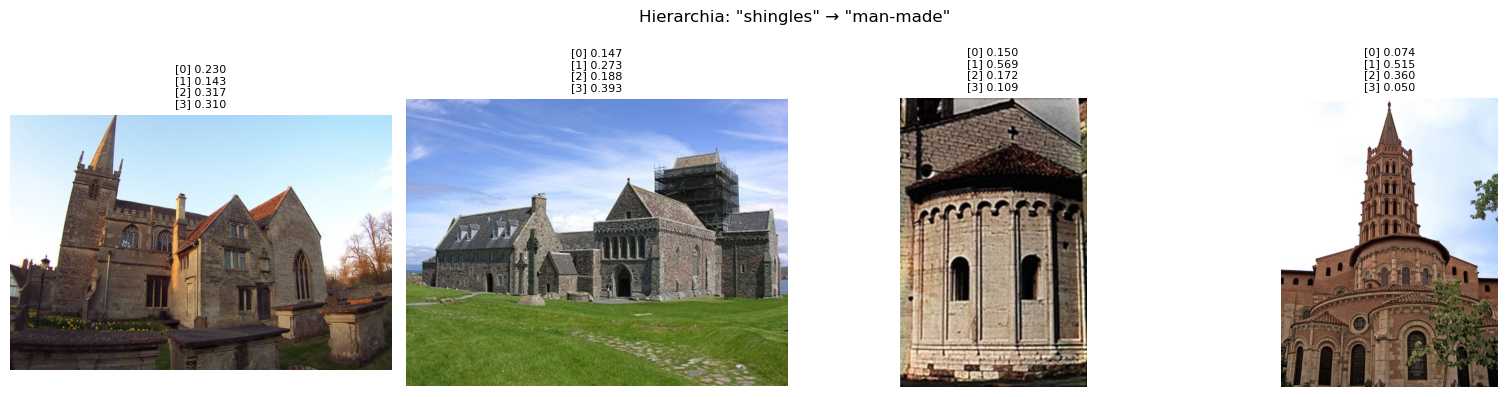

In [15]:
CONCEPT_A = 'shingles'   
CONCEPT_B = 'man-made'        

prompts = [
    f'a photo of a place that is {CONCEPT_A}',
    f'a photo of a place that is {CONCEPT_B}',
    f'a photo of a place that is {CONCEPT_A} and {CONCEPT_B}',
    f'a photo of an outdoor natural place',
]

with torch.no_grad():
    tokens  = clip.tokenize(prompts, truncate=True).to(DEVICE)
    text_fs = clip_model.encode_text(tokens).float()
    text_fs = text_fs / text_fs.norm(dim=-1, keepdim=True)

col_a = CONCEPT_A if CONCEPT_A in df_sun.columns else attr_cols[0]
sample_rows = df_sun[df_sun[col_a] == 1].head(4)

print(f'Prompty:')
for i, p in enumerate(prompts):
    print(f'  [{i}] {p}')
print()

fig, axes = plt.subplots(1, len(sample_rows), figsize=(16, 4))
with torch.no_grad():
    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img_path = os.path.join('data/SUN/images/', str(row['file_path']))
        img  = Image.open(img_path).convert('RGB')
        inp  = clip_preprocess(img).unsqueeze(0).to(DEVICE)
        feat = clip_model.encode_image(inp).squeeze().float()
        feat = feat / feat.norm()

        sims  = (feat @ text_fs.T).cpu().numpy()
        probs = np.exp(sims * 100) / np.exp(sims * 100).sum()

        ax.imshow(img)
        ax.set_title(
            '\n'.join([f'[{i}] {p:.3f}' for i, p in enumerate(probs)]),
            fontsize=8
        )
        ax.axis('off')

plt.suptitle(f'Hierarchia: "{CONCEPT_A}" → "{CONCEPT_B}"', fontsize=12)
plt.tight_layout()
plt.show()

Widzi dosyć słabo, może przez to, że "shingles" to też półpasiec?